# K-MEANS CLUSTERING #

* DATA

In [152]:
# import pandas as pd
# from sklearn.cluster import KMeans
# from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
# import matplotlib.pyplot as plt
# from sklearn.decomposition import PCA

In [153]:
import pandas as pd

# ==============================================================================
# DATA
# ==============================================================================
df_kmeans = pd.read_csv('dataset_final_skripsi_normalisasi.csv')
kolom_string = [
    'kode_provinsi',
    'kode_kabupaten_kota',
]

df_kmeans[kolom_string] = df_kmeans[kolom_string].astype(str)

kolom_numerik = [
    col for col in df_kmeans.select_dtypes(include='number').columns
    if col != 'tahun'
]

print("=========== DATA ===========")
df_kmeans

=========== DATA ===========


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,0.230769,-0.153846,-0.639716,-0.292108,-0.710573,-0.290467,-0.355131,-0.841177
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,0.461538,0.153846,-0.334074,-0.348645,-0.272298,-0.258875,-0.281465,-0.290178
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,-0.230769,0.153846,-0.573967,0.113074,-0.506202,-0.294463,-0.357889,-0.596418
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,0.615385,0.076923,-0.174145,0.282686,-0.144714,0.125248,-0.270435,-0.003479
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,0.000000,0.076923,-0.296757,0.141343,-0.453042,-0.154862,-0.315738,0.209405
...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,0.153846,-1.307692,-0.749889,-0.089517,-0.767277,-0.416321,-0.357101,-1.424734
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,0.000000,-1.307692,-0.810307,0.000000,-0.304194,-0.432294,-0.419342,-1.567573
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,0.000000,-1.307692,-0.618392,0.504122,0.273479,-0.388590,-0.172346,-1.455436
264,35,JAWA TIMUR,3578,KOTA SURABAYA,2024,2.615385,0.461538,2.427366,17.191991,12.351447,4.275868,0.435493,3.283073


* CLUSTERING

========== ELBOW METHOD ==========


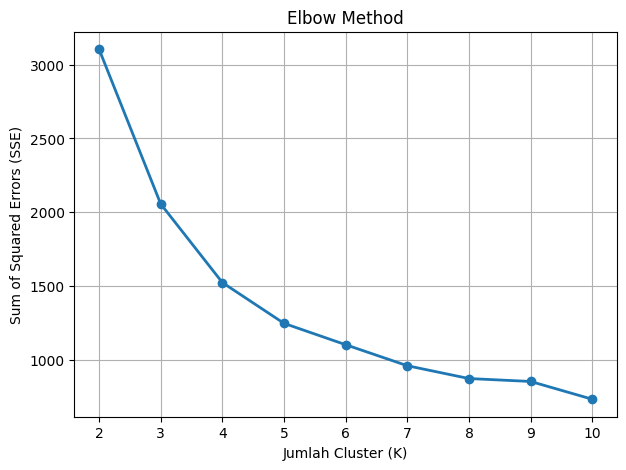

In [154]:

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# ==============================================================================
# 1. TENTUKAN JUMLAH CLUSTER (K)
# ==============================================================================

# --------------------------
# 1.1. ELBOW METHOD
# --------------------------

print("========== ELBOW METHOD ==========")

sse = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        # n_init=10,
        random_state=42
    )
    kmeans.fit(df_kmeans[kolom_numerik])
    sse.append(kmeans.inertia_)
    
plt.figure(figsize=(7,5))
plt.plot(
    K,
    sse,
    marker='o',
    linewidth=2
)

plt.title("Elbow Method")
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Sum of Squared Errors (SSE)")
plt.xticks(K)
plt.grid(True)

plt.show()

In [155]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# --------------------------
# 1.2. SILHOUETTE SCORE, DAVIES-BOULDIN INDEX, CALINSKI-HARABASZ INDEX
# --------------------------

hasil_evaluasi = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        # n_init=10,
        random_state=42
    )

    cluster = kmeans.fit_predict(df_kmeans[kolom_numerik])

    silhouette = silhouette_score(df_kmeans[kolom_numerik], cluster)
    dbi = davies_bouldin_score(df_kmeans[kolom_numerik], cluster)
    chi = calinski_harabasz_score(df_kmeans[kolom_numerik], cluster)

    hasil_evaluasi.append({
        'Jumlah Cluster (K)': k,
        'Silhouette Score': silhouette,
        'Davies-Bouldin Index': dbi,
        'Calinski-Harabasz Index': chi
    })

hasil_evaluasi = pd.DataFrame(hasil_evaluasi)

print("========== HASIL EVALUASI JUMLAH CLUSTER==========")
display(hasil_evaluasi.round(4))

========== HASIL EVALUASI JUMLAH CLUSTER==========


,Jumlah Cluster (K),Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,2,0.8887,0.2718,196.4649
1,3,0.6402,0.8335,214.8644
2,4,0.4425,0.7974,223.1382
3,5,0.2635,0.9655,218.1726
4,6,0.2495,1.0876,203.5416
5,7,0.2702,1.0509,200.4504
6,8,0.2534,0.9084,191.8531
7,9,0.2449,1.1895,171.8528
8,10,0.2609,0.9350,181.8464


In [156]:
# --------------------------
# 1.3. K OPTIMAL
# --------------------------

print("========== K OPTIMAL ==========")

k_optimal = hasil_evaluasi.loc[hasil_evaluasi['Silhouette Score'].idxmax(), 'Jumlah Cluster (K)']
print("1. K Optimal berdasarkan Silhouette Score:", k_optimal)

k_optimal = hasil_evaluasi.loc[hasil_evaluasi['Davies-Bouldin Index'].idxmin(), 'Jumlah Cluster (K)']
print("2. K Optimal berdasarkan Davies-Bouldin Index:", k_optimal)

k_optimal = hasil_evaluasi.loc[hasil_evaluasi['Calinski-Harabasz Index'].idxmax(), 'Jumlah Cluster (K)']
print("3. K Optimal berdasarkan Calinski-Harabasz Index:", k_optimal)


========== K OPTIMAL ==========
1. K Optimal berdasarkan Silhouette Score: 2
2. K Optimal berdasarkan Davies-Bouldin Index: 2
3. K Optimal berdasarkan Calinski-Harabasz Index: 4


_KLASTER OPTIMAL YANG DIGUNAKAN_

In [157]:
k = 2

In [158]:
from sklearn.cluster import KMeans

# ==============================================================================
# 2. PROSES K-MEANS CLUSTERING
# ==============================================================================

print("========== PROSES K-MEANS CLUSTERING ==========")

# --------------------------
# 2.1. INISIALISASI MODEL & PARAMETER K-MEANS
# --------------------------
kmeans = KMeans(
    n_clusters=k,
    init='k-means++',
    # n_init=10,
    random_state=42
)

# --------------------------
# 2.2. FIT MODEL K-MEANS
# --------------------------
kmeans.fit(df_kmeans[kolom_numerik])

# --------------------------
# 2.3. SIMPAN LABEL CLUSTER
# --------------------------
df_kmeans["cluster"] = kmeans.labels_ + 1

# --------------------------
# 2.4. JUMLAH ITERASI
# --------------------------
print("Jumlah iterasi :", kmeans.n_iter_)

========== PROSES K-MEANS CLUSTERING ==========
Jumlah iterasi : 2


In [159]:
# --------------------------
# 2.5. SIMPAN CENTROID
# --------------------------
centroid = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=kolom_numerik
)

centroid.insert(0, "Cluster", range(1, len(centroid) + 1))

print("========== CENTROID ==========")
display(centroid.round(4))

========== CENTROID ==========


,Cluster,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
0,1,0.2523,-0.0813,0.0393,0.5198,0.3770,0.2670,0.5566,0.0148
1,2,2.6923,0.3846,2.3136,21.3852,11.0284,1.4123,24.8812,3.2853


In [160]:
# ---------------------------
# 2.6. TABEL HASIL CLUSTERING K-MEANS
# ---------------------------

print("========== HASIL CLUSTERING K-MEANS ==========")

df_kmeans

========== HASIL CLUSTERING K-MEANS ==========


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk,cluster
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,0.230769,-0.153846,-0.639716,-0.292108,-0.710573,-0.290467,-0.355131,-0.841177,1
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,0.461538,0.153846,-0.334074,-0.348645,-0.272298,-0.258875,-0.281465,-0.290178,1
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,-0.230769,0.153846,-0.573967,0.113074,-0.506202,-0.294463,-0.357889,-0.596418,1
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,0.615385,0.076923,-0.174145,0.282686,-0.144714,0.125248,-0.270435,-0.003479,1
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,0.000000,0.076923,-0.296757,0.141343,-0.453042,-0.154862,-0.315738,0.209405,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,0.153846,-1.307692,-0.749889,-0.089517,-0.767277,-0.416321,-0.357101,-1.424734,1
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,0.000000,-1.307692,-0.810307,0.000000,-0.304194,-0.432294,-0.419342,-1.567573,1
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,0.000000,-1.307692,-0.618392,0.504122,0.273479,-0.388590,-0.172346,-1.455436,1
264,35,JAWA TIMUR,3578,KOTA SURABAYA,2024,2.615385,0.461538,2.427366,17.191991,12.351447,4.275868,0.435493,3.283073,1


In [161]:
# ---------------------------
# 2.7. JUMLAH ANGGOTA CLUSTER
# ---------------------------

print("========== JUMLAH ANGGOTA CLUSTER ==========")

jumlah_cluster = (
    df_kmeans["cluster"]
    .value_counts()
    .sort_index()
)

display(jumlah_cluster)

========== JUMLAH ANGGOTA CLUSTER ==========


cluster
1    264
2      2
Name: count, dtype: int64

* EVALUASI

In [162]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# ==============================================================================
# 3. EVALUASI HASIL CLUSTERING K-MEANS
# ==============================================================================

silhouette = silhouette_score(
    df_kmeans[kolom_numerik],
    df_kmeans['cluster']
)

dbi = davies_bouldin_score(
    df_kmeans[kolom_numerik],
    df_kmeans['cluster']
)

chi = calinski_harabasz_score(
    df_kmeans[kolom_numerik],
    df_kmeans['cluster']
)

print("========== HASIL EVALUASI K-MEANS ==========")
print(f"Silhouette Score        : {silhouette:.4f}")
print(f"Davies-Bouldin Index    : {dbi:.4f}")
print(f"Calinski-Harabasz Index : {chi:.4f}")

========== HASIL EVALUASI K-MEANS ==========
Silhouette Score        : 0.8887
Davies-Bouldin Index    : 0.2718
Calinski-Harabasz Index : 196.4649


* VISUALISASI

========== VISUALISASI HASIL CLUSTERING ==========


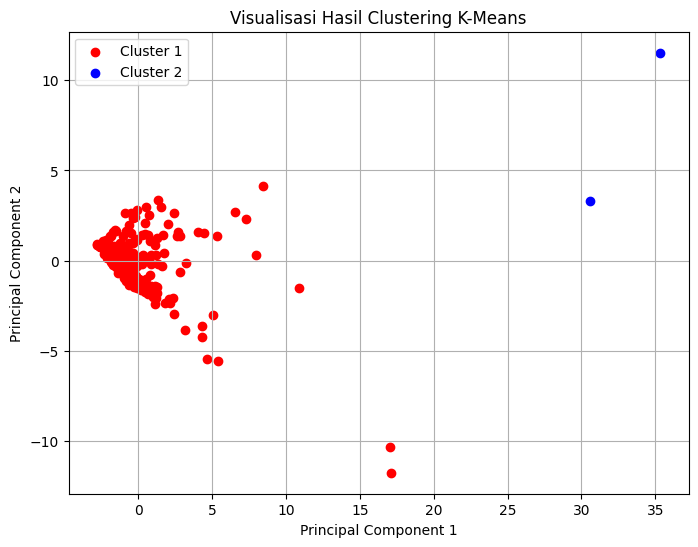

In [163]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ==========================================================
# VISUALISASI HASIL CLUSTERING
# ==========================================================

print("========== VISUALISASI HASIL CLUSTERING ==========")

pca = PCA(n_components=8)

pca_result = pca.fit_transform(df_kmeans[kolom_numerik])

df_pca = pd.DataFrame(pca_result, columns=[f"PC{i+1}" for i in range(8)])

df_pca["cluster"] = (kmeans.labels_ + 1)

plt.figure(figsize=(8, 6))

color_map = {1: 'red', 2: 'blue'}

for cluster in sorted(
    df_pca["cluster"].unique()
):
    subset = df_pca[
        df_pca["cluster"] == cluster
    ]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Cluster {cluster}",
        color=color_map[cluster]
    )

plt.title("Visualisasi Hasil Clustering K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()

In [164]:
import plotly.express as px
from sklearn.decomposition import PCA

# ==========================================================
# PCA 3D
# ==========================================================

pca = PCA(n_components=3)

pca_result = pca.fit_transform(
    df_kmeans[kolom_numerik]
)

df_pca = pd.DataFrame(
    pca_result,
    columns=['PC1', 'PC2', 'PC3']
)

df_pca['cluster'] = df_kmeans['cluster'].values

df_pca['nama_kabupaten_kota'] = (
    df_kmeans['nama_kabupaten_kota'].values
)

df_pca['tahun'] = df_kmeans['tahun'].values

# ==========================================================
# VISUALISASI PCA 3D INTERAKTIF
# ==========================================================

fig = px.scatter_3d(
    df_pca,
    x='PC1',
    y='PC2',
    z='PC3',
    color='cluster',
    color_continuous_scale=px.colors.qualitative.Set1,
    hover_name='nama_kabupaten_kota',
    hover_data=['tahun'],
    title='Visualisasi Cluster dalam PCA 3D'
)

fig.update_traces(
    marker=dict(size=5)
)

fig.update_layout(
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3'
    )
)

fig.show()

# _SUB CLUSTER_ #

* K OPTIMAL SUB-CLUSTER

In [165]:
# from sklearn.cluster import KMeans
# from sklearn.metrics import (silhouette_score, davies_bouldin_score, calinski_harabasz_score)
# import pandas as pd
# from sklearn.decomposition import PCA
# import matplotlib.pyplot as plt

In [166]:
# ==========================================================
# 1. EVALUASI K SUB-CLUSTER
# ==========================================================

print("========== EVALUASI K SUB-CLUSTER ==========")

# ---------------------------
# 1.1. CLUSTER UTAMA 
# ---------------------------

# sub-cluster hanya untuk cluster utama cluster 1
df_kmeans_sub = df_kmeans.loc[
    df_kmeans['cluster'] == 1
].copy()

print("Jumlah data Cluster Utama 1 :", len(df_kmeans_sub))

========== EVALUASI K SUB-CLUSTER ==========
Jumlah data Cluster Utama 1 : 264


In [167]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# ---------------------------
# 1.2. EVALUASI K SUB-CLUSTER 
# ---------------------------
max_k_cluster = min(10, len(df_kmeans_sub) - 1)


evaluasi_subcluster = []

for k in range(2, max_k_cluster + 1):

    kmeans_sub = KMeans(
        n_clusters=k,
        init='k-means++',
        # n_init=10,
        random_state=42
    )

    labels_sub = kmeans_sub.fit_predict(df_kmeans_sub[kolom_numerik])

    silhouette = silhouette_score(df_kmeans_sub[kolom_numerik], labels_sub)
    dbi = davies_bouldin_score(df_kmeans_sub[kolom_numerik], labels_sub)
    chi = calinski_harabasz_score(df_kmeans_sub[kolom_numerik], labels_sub)

    evaluasi_subcluster.append({
        'Cluster Utama': 1,
        'Jumlah Sub Cluster (K)': k,
        'Silhouette Score': silhouette,
        'Davies-Bouldin Index': dbi,
        'Calinski-Harabasz Index': chi
    })

print("\n=== HASIL EVALUASI SUB-CLUSTER ===")

df_evaluasi_subcluster = pd.DataFrame(evaluasi_subcluster)

df_evaluasi_subcluster = df_evaluasi_subcluster.sort_values(
    ['Cluster Utama', 'Jumlah Sub Cluster (K)']
).reset_index(drop=True)

df_evaluasi_subcluster.round(4)


=== HASIL EVALUASI SUB-CLUSTER ===


,Cluster Utama,Jumlah Sub Cluster (K),Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,1,2,0.8349,0.1594,108.5714
1,1,3,0.2963,1.3146,119.4047
2,1,4,0.2378,1.2978,101.6242
3,1,5,0.2488,1.1934,128.5202
4,1,6,0.2883,0.9842,134.5565
5,1,7,0.2600,1.2293,118.2873
6,1,8,0.2691,1.1095,122.8151
7,1,9,0.2708,1.1323,117.2069
8,1,10,0.2783,1.1344,112.8337


In [168]:
# --------------------------
# 1.3. K OPTIMAL SUB-CLUSTER
# --------------------------

print("========== K OPTIMAL SUB-CLUSTER ==========")

k_optimal = df_evaluasi_subcluster.loc[df_evaluasi_subcluster['Silhouette Score'].idxmax(), 'Jumlah Sub Cluster (K)']
print("1. K Optimal Sub-Cluster berdasarkan Silhouette Score:", k_optimal)

k_optimal = df_evaluasi_subcluster.loc[df_evaluasi_subcluster['Davies-Bouldin Index'].idxmin(), 'Jumlah Sub Cluster (K)']
print("2. K Optimal Sub-Cluster berdasarkan Davies-Bouldin Index:", k_optimal)

k_optimal = df_evaluasi_subcluster.loc[df_evaluasi_subcluster['Calinski-Harabasz Index'].idxmax(), 'Jumlah Sub Cluster (K)']
print("3. K Optimal Sub-Cluster berdasarkan Calinski-Harabasz Index:", k_optimal)

========== K OPTIMAL SUB-CLUSTER ==========
1. K Optimal Sub-Cluster berdasarkan Silhouette Score: 2
2. K Optimal Sub-Cluster berdasarkan Davies-Bouldin Index: 2
3. K Optimal Sub-Cluster berdasarkan Calinski-Harabasz Index: 6


* CLUSTERING

In [169]:
from sklearn.cluster import KMeans

# ==========================================================
# 2. CLUSTERING SUB-CLUSTER
# ==========================================================

print("========== PROSES K-MEANS SUB-CLUSTERING ==========")

# --------------------------
# 2.1. INISIALISASI MODEL & PARAMETER K-MEANS
# --------------------------
k_sub = 2
kmeans_sub = KMeans(
    n_clusters=int(k_sub),
    init='k-means++',
    # n_init=10,
    random_state=42
)

# --------------------------
# 2.2. FIT MODEL K-MEANS
# --------------------------
kmeans_sub.fit(df_kmeans_sub[kolom_numerik])

# --------------------------
# 2.3. SIMPAN LABEL SUB-CLUSTER
# --------------------------
df_kmeans_sub["sub_cluster"] = kmeans_sub.labels_ + 1

# --------------------------
# 2.4. JUMLAH ITERASI
# --------------------------
print("Jumlah iterasi :", kmeans_sub.n_iter_)

========== PROSES K-MEANS SUB-CLUSTERING ==========
Jumlah iterasi : 2


In [170]:
# --------------------------
# 2.5. SIMPAN CENTROID
# --------------------------
centroid = pd.DataFrame(
    kmeans_sub.cluster_centers_,
    columns=kolom_numerik
)

centroid.insert(0, "Cluster", range(1, len(centroid) + 1))

print("========== CENTROID ==========")
display(centroid.round(4))

========== CENTROID ==========


,Cluster,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
0,1,0.2340,-0.0851,0.0179,0.3961,0.2887,0.2358,0.5525,-0.0102
1,2,2.6538,0.4231,2.8334,16.7326,11.9427,4.3437,1.1005,3.2960


In [171]:
# ---------------------------
# 2.6. TABEL HASIL SUB-CLUSTERING K-MEANS
# ---------------------------

print("========== HASIL SUB-CLUSTERING K-MEANS ==========")

df_kmeans_sub

========== HASIL SUB-CLUSTERING K-MEANS ==========


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk,cluster,sub_cluster
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,0.230769,-0.153846,-0.639716,-0.292108,-0.710573,-0.290467,-0.355131,-0.841177,1,1
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,0.461538,0.153846,-0.334074,-0.348645,-0.272298,-0.258875,-0.281465,-0.290178,1,1
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,-0.230769,0.153846,-0.573967,0.113074,-0.506202,-0.294463,-0.357889,-0.596418,1,1
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,0.615385,0.076923,-0.174145,0.282686,-0.144714,0.125248,-0.270435,-0.003479,1,1
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,0.000000,0.076923,-0.296757,0.141343,-0.453042,-0.154862,-0.315738,0.209405,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,0.153846,-1.307692,-0.749889,-0.089517,-0.767277,-0.416321,-0.357101,-1.424734,1,1
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,0.000000,-1.307692,-0.810307,0.000000,-0.304194,-0.432294,-0.419342,-1.567573,1,1
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,0.000000,-1.307692,-0.618392,0.504122,0.273479,-0.388590,-0.172346,-1.455436,1,1
264,35,JAWA TIMUR,3578,KOTA SURABAYA,2024,2.615385,0.461538,2.427366,17.191991,12.351447,4.275868,0.435493,3.283073,1,2


In [172]:
# ---------------------------
# 2.7. JUMLAH ANGGOTA SUB-CLUSTER
# ---------------------------

print("========== JUMLAH ANGGOTA SUB-CLUSTER ==========")

jumlah_cluster = (
    df_kmeans_sub["sub_cluster"]
    .value_counts()
    .sort_index()
)

display(jumlah_cluster)

========== JUMLAH ANGGOTA SUB-CLUSTER ==========


sub_cluster
1    262
2      2
Name: count, dtype: int64

* EVALUASI

In [173]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# ==============================================================================
# 3. EVALUASI HASIL SUB-CLUSTERING K-MEANS
# ==============================================================================

silhouette = silhouette_score(
    df_kmeans_sub[kolom_numerik],
    df_kmeans_sub['sub_cluster']
)

dbi = davies_bouldin_score(
    df_kmeans_sub[kolom_numerik],
    df_kmeans_sub['sub_cluster']
)

chi = calinski_harabasz_score(
    df_kmeans_sub[kolom_numerik],
    df_kmeans_sub['sub_cluster']
)

print("========== HASIL EVALUASI SUB-CLUSTER K-MEANS ==========")
print(f"Silhouette Score        : {silhouette:.4f}")
print(f"Davies-Bouldin Index    : {dbi:.4f}")
print(f"Calinski-Harabasz Index : {chi:.4f}")

========== HASIL EVALUASI SUB-CLUSTER K-MEANS ==========
Silhouette Score        : 0.8349
Davies-Bouldin Index    : 0.1594
Calinski-Harabasz Index : 108.5714


* VISUALISASI

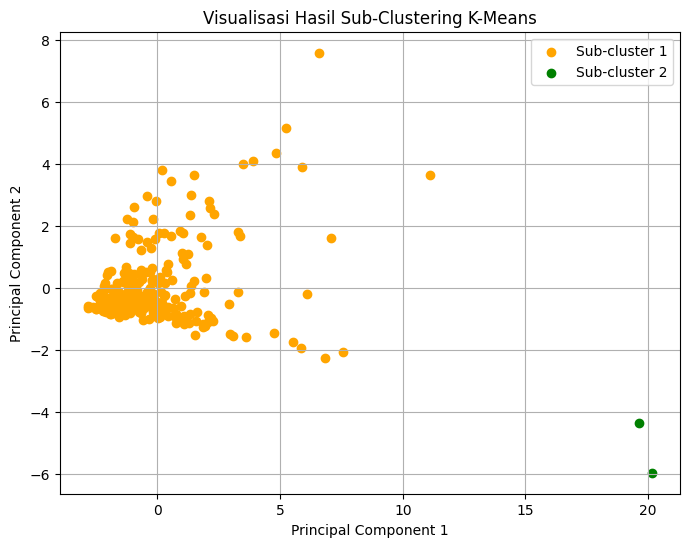

In [174]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ==========================================================
# VISUALISASI SUB-CLUSTER
# ==========================================================

pca = PCA(n_components=8)

pca_result = pca.fit_transform(df_kmeans_sub[kolom_numerik])

df_pca = pd.DataFrame(pca_result, columns=[f"PC{i+1}" for i in range(8)])

df_pca["sub_cluster"] = (kmeans_sub.labels_ + 1)

plt.figure(figsize=(8, 6))

color_map = {1: 'orange', 2: 'green'}

for sub_cluster in sorted(
    df_pca["sub_cluster"].unique()
):
    subset = df_pca[
        df_pca["sub_cluster"] == sub_cluster
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Sub-cluster {sub_cluster}",
        color=color_map[sub_cluster]
    )

plt.title("Visualisasi Hasil Sub-Clustering K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()

In [175]:
import plotly.express as px
from sklearn.decomposition import PCA

# ==========================================================
# PCA 3D
# ==========================================================

pca = PCA(n_components=3)

pca_result = pca.fit_transform(
    df_kmeans_sub[kolom_numerik]
)

df_pca = pd.DataFrame(
    pca_result,
    columns=['PC1', 'PC2', 'PC3']
)

df_pca['sub_cluster'] = df_kmeans_sub['sub_cluster'].values

df_pca['nama_kabupaten_kota'] = (
    df_kmeans_sub['nama_kabupaten_kota'].values
)

df_pca['tahun'] = df_kmeans_sub['tahun'].values

# ==========================================================
# VISUALISASI PCA 3D INTERAKTIF
# ==========================================================

fig = px.scatter_3d(
    df_pca,
    x='PC1',
    y='PC2',
    z='PC3',
    color='sub_cluster',
    color_continuous_scale=px.colors.qualitative.Set1,
    hover_name='nama_kabupaten_kota',
    hover_data=['tahun'],
    title='Visualisasi Sub-Cluster dalam PCA 3D'
)

fig.update_traces(
    marker=dict(size=5)
)

fig.update_layout(
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3'
    )
)

fig.show()

# _SIMPAN DATA_ 

In [176]:
# ==============================================================================
# SIMPAN HASIL CLUSTERING K-MEANS
# ==============================================================================

df_hasil_kmeans_norm = df_kmeans.copy()

df_hasil_kmeans_norm["cluster"] = kmeans.labels_ + 1
df_hasil_kmeans_norm["sub_cluster"] = 0

df_hasil_kmeans_sub = df_hasil_kmeans_norm[
    df_hasil_kmeans_norm["cluster"] == 1
].index
df_hasil_kmeans_norm.loc[
    df_hasil_kmeans_sub,
    "sub_cluster"
] = kmeans_sub.labels_ + 1

print("========== SIMPAN HASIL CLUSTERING K-MEANS ==========")
display(df_hasil_kmeans_norm)

========== SIMPAN HASIL CLUSTERING K-MEANS ==========


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk,cluster,sub_cluster
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,0.230769,-0.153846,-0.639716,-0.292108,-0.710573,-0.290467,-0.355131,-0.841177,1,1
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,0.461538,0.153846,-0.334074,-0.348645,-0.272298,-0.258875,-0.281465,-0.290178,1,1
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,-0.230769,0.153846,-0.573967,0.113074,-0.506202,-0.294463,-0.357889,-0.596418,1,1
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,0.615385,0.076923,-0.174145,0.282686,-0.144714,0.125248,-0.270435,-0.003479,1,1
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,0.000000,0.076923,-0.296757,0.141343,-0.453042,-0.154862,-0.315738,0.209405,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,0.153846,-1.307692,-0.749889,-0.089517,-0.767277,-0.416321,-0.357101,-1.424734,1,1
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,0.000000,-1.307692,-0.810307,0.000000,-0.304194,-0.432294,-0.419342,-1.567573,1,1
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,0.000000,-1.307692,-0.618392,0.504122,0.273479,-0.388590,-0.172346,-1.455436,1,1
264,35,JAWA TIMUR,3578,KOTA SURABAYA,2024,2.615385,0.461538,2.427366,17.191991,12.351447,4.275868,0.435493,3.283073,1,2


In [177]:
#===============================================================================
# SIMPAN DATA
#===============================================================================
df_hasil_kmeans_norm.to_csv('data_clustering_kmeans_normalized.csv', index=False)

In [178]:
import pandas as pd

# ==============================================================================
# SIMPAN HASIL CLUSTERING K-MEANS (DATA ASLI)
# ==============================================================================

df_hasil_kmeans = pd.read_csv('dataset_final_skripsi.csv').copy()

df_hasil_kmeans["cluster"] = kmeans.labels_ + 1
df_hasil_kmeans["sub_cluster"] = 0

df_hasil_kmeans_sub = df_hasil_kmeans[
    df_hasil_kmeans["cluster"] == 1
].index
df_hasil_kmeans.loc[
    df_hasil_kmeans_sub,
    "sub_cluster"
] = kmeans_sub.labels_ + 1

print("========== SIMPAN HASIL CLUSTERING K-MEANS (DATA ASLI) ==========")
display(df_hasil_kmeans)

========== SIMPAN HASIL CLUSTERING K-MEANS (DATA ASLI) ==========


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk,cluster,sub_cluster
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,9,15,347,141,619,41173,292,554394,1,1
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,12,19,519,129,990,46778,479,870705,1,1
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,3,19,384,227,792,40464,285,694902,1,1
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,14,18,609,263,1098,114929,507,1035290,1,1
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,6,18,540,233,837,65232,392,1157500,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,8,0,285,184,571,18844,287,219392,1,1
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,6,0,251,203,963,16010,129,137393,1,1
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,6,0,359,310,1452,23764,756,201767,1,1
264,35,JAWA TIMUR,3578,KOTA SURABAYA,2024,40,23,2073,3852,11676,851331,2299,2921996,1,2


In [179]:
#===============================================================================
# SIMPAN DATA
#===============================================================================
df_hasil_kmeans.to_csv('data_clustering_kmeans.csv', index=False)

# _VISUALISASI_

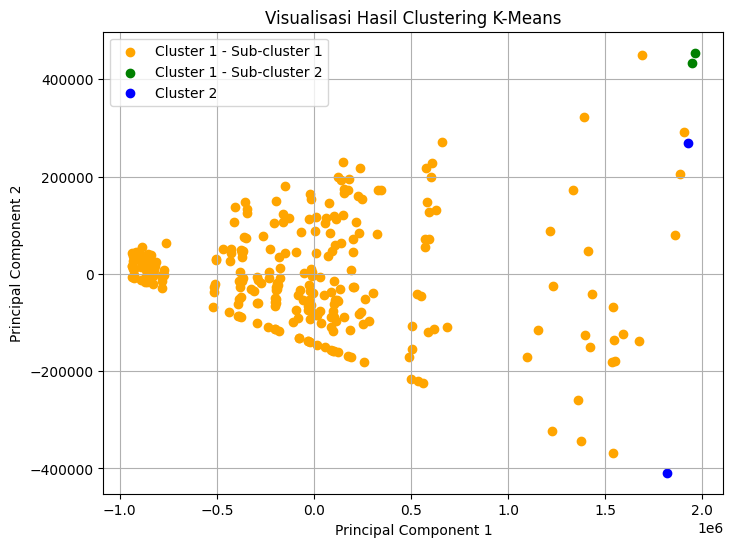

In [180]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ==========================================================
# VISUALISASI HASIL CLUSTERING K-MEANS
# ==========================================================

pca = PCA(n_components=8)

pca_result = pca.fit_transform(
    df_hasil_kmeans[kolom_numerik]
)

df_pca = pd.DataFrame(
    pca_result,
    columns=[f"PC{i+1}" for i in range(8)]
)

df_pca["cluster"] = df_hasil_kmeans["cluster"].values
df_pca["sub_cluster"] = df_hasil_kmeans["sub_cluster"].values


plt.figure(figsize=(8, 6))

# --------------------------
# Cluster 1 - Sub-cluster
# --------------------------
color_map = {1: 'orange', 2: 'green'}

for sub_cluster in sorted(
    df_pca.loc[
        df_pca["cluster"] == 1,
        "sub_cluster"
    ].unique()
):

    subset = df_pca[
        (df_pca["cluster"] == 1) &
        (df_pca["sub_cluster"] == sub_cluster)
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Cluster 1 - Sub-cluster {sub_cluster}",
        color=color_map[sub_cluster]
    )


# --------------------------
# Cluster 2
# --------------------------

subset_cluster2 = df_pca[
    df_pca["cluster"] == 2
]

plt.scatter(
    subset_cluster2["PC1"],
    subset_cluster2["PC2"],
    label="Cluster 2",
    color='blue'
)

plt.title("Visualisasi Hasil Clustering K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()

In [181]:
import plotly.express as px
from sklearn.decomposition import PCA

# ==========================================================
# PCA 3D
# ==========================================================

pca = PCA(n_components=3)

pca_result = pca.fit_transform(
    df_hasil_kmeans[kolom_numerik]
)

df_pca = pd.DataFrame(
    pca_result,
    columns=['PC1', 'PC2', 'PC3']
)

# ==========================================================
# TAMBAHKAN INFORMASI CLUSTER
# ==========================================================

df_pca['cluster'] = df_hasil_kmeans['cluster'].values
df_pca['sub_cluster'] = df_hasil_kmeans['sub_cluster'].values

df_pca['nama_kabupaten_kota'] = (
    df_hasil_kmeans['nama_kabupaten_kota'].values
)

df_pca['tahun'] = (
    df_hasil_kmeans['tahun'].values
)

# ==========================================================
# BUAT LABEL VISUALISASI
# ==========================================================

df_pca['label_cluster'] = df_pca.apply(
    lambda row:
        f"Cluster 1 - Sub-cluster {int(row['sub_cluster'])}"
        if row['cluster'] == 1
        else "Cluster 2",
    axis=1
)

# ==========================================================
# VISUALISASI PCA 3D INTERAKTIF
# ==========================================================

fig = px.scatter_3d(
    df_pca,
    x='PC1',
    y='PC2',
    z='PC3',
    color='label_cluster',
    color_discrete_sequence=px.colors.qualitative.Set1,
    hover_name='nama_kabupaten_kota',
    hover_data=['tahun'],
    title='Visualisasi Hasil Clustering K-Means dalam PCA 3D'
)

fig.update_traces(
    marker=dict(size=5)
)

fig.update_layout(
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3'
    )
)

fig.show()

# _KARAKTERISTIK CLUSTER_

========== KARAKTERISTIK CLUSTER UTAMA ==========


,Jumlah Anggota,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
cluster,,,,,,,,,
1,264,9.2803,15.9432,729.1023,313.3371,1539.6553,140071.7311,2606.5227,1.045794e+06
2,2,41.0000,22.0000,2009.0000,4742.0000,10556.0000,343275.5000,64354.5000,2.923300e+06


========== KARAKTERISTIK CLUSTER UTAMA 1 | SUB-CLUSTER ==========


,Jumlah Anggota,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
sub_cluster,,,,,,,,,
1,262,9.042,15.8931,717.0992,287.0687,1464.9198,134550.3626,2595.9847,1.031416e+06
2,2,40.500,22.5000,2301.5000,3754.5000,11330.0000,863371.0000,3987.0000,2.929414e+06


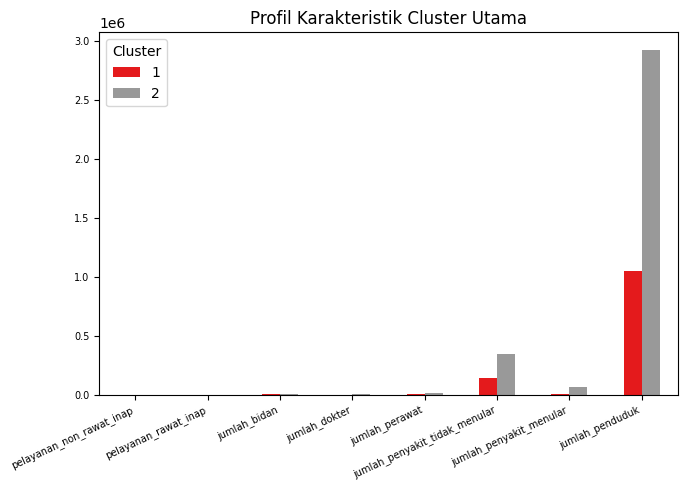

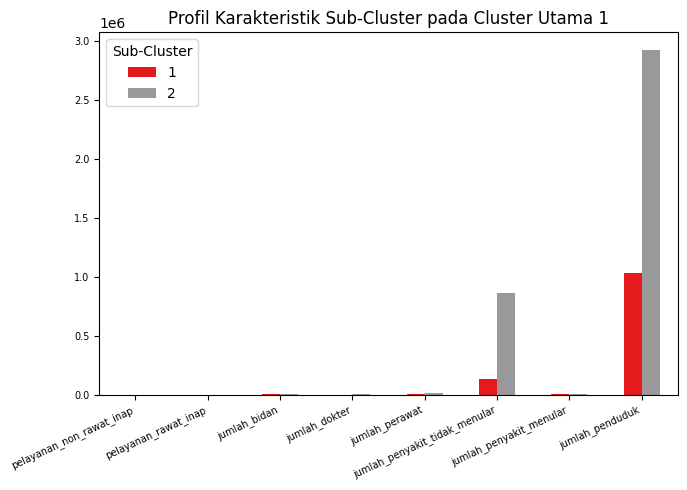

In [182]:
# ==========================================================
# PROFIL / KARAKTERISTIK CLUSTER
# ==========================================================

df_profil = df_hasil_kmeans.copy()

# ----------------------------------------------------------
# 1. PROFIL CLUSTER UTAMA
# ----------------------------------------------------------

profil_cluster = (
    df_profil
    .groupby('cluster')[kolom_numerik]
    .mean()
)

jumlah_cluster = (
    df_profil['cluster']
    .value_counts()
    .sort_index()
)

profil_cluster_lengkap = profil_cluster.copy()

profil_cluster_lengkap.insert(
    0, 'Jumlah Anggota', jumlah_cluster
)

print("========== KARAKTERISTIK CLUSTER UTAMA ==========")
display(profil_cluster_lengkap.round(4))


# ----------------------------------------------------------
# 2. PROFIL SUB-CLUSTER CLUSTER UTAMA 1
# ----------------------------------------------------------

df_cluster1 = df_profil[
    df_profil['cluster'] == 1
].copy()

profil_subcluster = (
    df_cluster1
    .groupby('sub_cluster')[kolom_numerik]
    .mean()
)

jumlah_subcluster = (
    df_cluster1['sub_cluster']
    .value_counts()
    .sort_index()
)

profil_subcluster_lengkap = profil_subcluster.copy()

profil_subcluster_lengkap.insert(0, 'Jumlah Anggota', jumlah_subcluster)

print("========== KARAKTERISTIK CLUSTER UTAMA 1 | SUB-CLUSTER ==========")
display(profil_subcluster_lengkap.round(4))


# ----------------------------------------------------------
# 3. VISUALISASI PROFIL CLUSTER UTAMA
# ----------------------------------------------------------

profil_cluster.T.plot(
    kind='bar',
    figsize=(7, 5),
    fontsize=7,
    colormap='Set1'
)

plt.title("Profil Karakteristik Cluster Utama")
plt.xticks(rotation=25, ha='right')
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


# ----------------------------------------------------------
# 4. VISUALISASI PROFIL SUB-CLUSTER
# ----------------------------------------------------------

profil_subcluster.T.plot(
    kind='bar',
    figsize=(7, 5),
    fontsize=7,
    colormap='Set1'
)

plt.title("Profil Karakteristik Sub-Cluster pada Cluster Utama 1")
plt.xticks(rotation=25, ha='right')
plt.legend(title="Sub-Cluster")
plt.tight_layout()
plt.show()

In [183]:
df_hasil_kmeans_normalisasi = pd.read_csv('dataset_final_skripsi_normalisasi.csv').copy()

df_hasil_kmeans_normalisasi["cluster"] = kmeans.labels_ + 1
df_hasil_kmeans_normalisasi["sub_cluster"] = 0

df_hasil_kmeans_sub = df_hasil_kmeans_normalisasi[
    df_hasil_kmeans_normalisasi["cluster"] == 1
].index
df_hasil_kmeans_normalisasi.loc[
    df_hasil_kmeans_sub,
    "sub_cluster"
] = kmeans_sub.labels_ + 1

print("========== SIMPAN HASIL CLUSTERING K-MEANS ==========")
display(df_hasil_kmeans_normalisasi)

========== SIMPAN HASIL CLUSTERING K-MEANS ==========


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk,cluster,sub_cluster
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,0.230769,-0.153846,-0.639716,-0.292108,-0.710573,-0.290467,-0.355131,-0.841177,1,1
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,0.461538,0.153846,-0.334074,-0.348645,-0.272298,-0.258875,-0.281465,-0.290178,1,1
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,-0.230769,0.153846,-0.573967,0.113074,-0.506202,-0.294463,-0.357889,-0.596418,1,1
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,0.615385,0.076923,-0.174145,0.282686,-0.144714,0.125248,-0.270435,-0.003479,1,1
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,0.000000,0.076923,-0.296757,0.141343,-0.453042,-0.154862,-0.315738,0.209405,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,0.153846,-1.307692,-0.749889,-0.089517,-0.767277,-0.416321,-0.357101,-1.424734,1,1
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,0.000000,-1.307692,-0.810307,0.000000,-0.304194,-0.432294,-0.419342,-1.567573,1,1
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,0.000000,-1.307692,-0.618392,0.504122,0.273479,-0.388590,-0.172346,-1.455436,1,1
264,35,JAWA TIMUR,3578,KOTA SURABAYA,2024,2.615385,0.461538,2.427366,17.191991,12.351447,4.275868,0.435493,3.283073,1,2
